# CIFAR-10 — Comparaison des optimiseurs
**EFREI Paris — Optimisation Convexe**

Comparaison de 5 optimiseurs : SGD, SGD+Momentum, RMSProp, Adam, Muon

## 1. Imports

### Initialisation de l'environnement
Importe les bibliothèques nécessaires, détecte le périphérique de calcul disponible (`cuda` ou `cpu`) et affiche la version de PyTorch utilisée.


In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import wandb
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# DEVICE = torch.device("mps")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

PyTorch: 2.12.0+cu130
Device : cuda


### Notes de travail
Cellule de notes temporaires indiquant les ajustements prévus pour le scheduler, Muon et le projet Weights & Biases.


## 2. Learning Rate Scheduler
Au lieu de chercher un learning rate par grid search, on fixe un learning rate initial par optimiseur et on applique un scheduler pendant l'entraînement.

Le scheduler utilisé dans la boucle principale est `CosineAnnealingLR` : le learning rate diminue progressivement pendant les 30 époques, ce qui évite de lancer plusieurs entraînements complets pour tester une grille de valeurs.

### Configuration scheduler
Cette section remplace l'ancien grid search. Les optimiseurs sont comparés avec leur learning rate initial et un scheduler identique dans la boucle d'entraînement principale.

In [54]:
# Le grid search est remplacé par le scheduler défini dans la configuration principale.
# Les données train/validation/test sont préparées plus bas pour l'entraînement final.
print("Grid search désactivé : utilisation d'un learning-rate scheduler pendant l'entraînement.")

Grid search désactivé : utilisation d'un learning-rate scheduler pendant l'entraînement.


### Ancien grid search désactivé
Le choix du learning rate ne se fait plus par grille. La cellule suivante est volontairement vide pour conserver la structure du notebook.

In [55]:
# Ancien grid search désactivé.
# Voir la cellule de configuration principale pour le scheduler.
pass

### Courbe de scheduler
La visualisation du learning rate est maintenant produite par Weights & Biases via la métrique `lr`.

In [56]:
# Ancienne analyse des meilleurs learning rates désactivée.
# Les courbes de validation sont tracées après l'entraînement principal.
pass

## 3. Configuration

### Paramètres globaux de l'expérience
Fixe la graine aléatoire, le nombre d'époques, la taille des batchs, la liste des optimiseurs comparés et les couleurs utilisées pour les visualisations.


In [57]:
SEED       = 42
NUM_EPOCHS = 30
BATCH_SIZE = 128

TRAIN_SIZE = 45_000
VAL_SIZE   = 5_000
SCHEDULER_ETA_MIN_RATIO = 0.01


torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs("results", exist_ok=True)

# (name, optimizer class, kwargs)
OPTIMIZERS = [
    ("SGD",          optim.SGD,     {"lr": 0.01}),
    ("SGD+Momentum", optim.SGD,     {"lr": 0.01, "momentum": 0.9}),
    ("RMSProp",      optim.RMSprop, {"lr": 0.001, "alpha": 0.9}),
    ("Adam",         optim.Adam,    {"lr": 0.001, "betas": (0.9, 0.999)}),
    ("Muon",         optim.Muon,    {"lr": 0.001, "adamw_lr": 0.001}),
]

COLORS = {
    "SGD": "#e41a1c",
    "SGD+Momentum": "#ff7f00",
    "RMSProp": "#377eb8",
    "Adam": "#984ea3",
    "Muon": "#3cb44b",
}


def make_optimizer(model, opt_name, opt_cls, opt_kwargs):
    if opt_name != "Muon":
        return opt_cls(model.parameters(), **opt_kwargs)

    lr = opt_kwargs["lr"]
    adamw_lr = opt_kwargs.get("adamw_lr", lr)
    muon_kwargs = {k: v for k, v in opt_kwargs.items() if k not in ("lr", "adamw_lr")}
    matrix_params = [p for p in model.parameters() if p.requires_grad and p.ndim == 2]
    other_params = [p for p in model.parameters() if p.requires_grad and p.ndim != 2]

    optimizers = []
    if matrix_params:
        optimizers.append(optim.Muon(matrix_params, lr=lr, **muon_kwargs))
    if other_params:
        optimizers.append(optim.AdamW(other_params, lr=adamw_lr))
    return optimizers


def zero_grad_all(optimizer):
    if isinstance(optimizer, (list, tuple)):
        for opt in optimizer:
            opt.zero_grad()
    else:
        optimizer.zero_grad()


def step_all(optimizer):
    if isinstance(optimizer, (list, tuple)):
        for opt in optimizer:
            opt.step()
    else:
        optimizer.step()


def make_scheduler(optimizer):
    if isinstance(optimizer, (list, tuple)):
        return [
            optim.lr_scheduler.CosineAnnealingLR(
                opt,
                T_max=NUM_EPOCHS,
                eta_min=opt.param_groups[0]["lr"] * SCHEDULER_ETA_MIN_RATIO,
            )
            for opt in optimizer
        ]
    return optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS,
        eta_min=optimizer.param_groups[0]["lr"] * SCHEDULER_ETA_MIN_RATIO,
    )


def scheduler_step_all(scheduler):
    if isinstance(scheduler, (list, tuple)):
        for sched in scheduler:
            sched.step()
    else:
        scheduler.step()


def current_lr(optimizer):
    if isinstance(optimizer, (list, tuple)):
        return optimizer[0].param_groups[0]["lr"]
    return optimizer.param_groups[0]["lr"]


print("Config OK")

Config OK


## 4. Données CIFAR-10

### Chargement des données CIFAR-10
Définit les transformations d'entraînement et de test, télécharge les jeux de données CIFAR-10, puis crée les `DataLoader` principaux pour l'entraînement final.


In [58]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_train_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
full_train_eval = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_eval)
testset         = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_eval)

split_generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = torch.utils.data.random_split(
    range(len(full_train_aug)),
    [TRAIN_SIZE, VAL_SIZE],
    generator=split_generator,
)
train_idx = train_subset.indices
val_idx   = val_subset.indices

trainset      = torch.utils.data.Subset(full_train_aug, train_idx)
train_evalset = torch.utils.data.Subset(full_train_eval, train_idx)
valset        = torch.utils.data.Subset(full_train_eval, val_idx)

trainloader      = torch.utils.data.DataLoader(trainset,      batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
train_eval_loader = torch.utils.data.DataLoader(train_evalset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
valloader        = torch.utils.data.DataLoader(valset,        batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader       = torch.utils.data.DataLoader(testset,       batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train : {len(trainset):,} images")
print(f"Val   : {len(valset):,} images")
print(f"Test  : {len(testset):,} images")

Train : 45,000 images
Val   : 5,000 images
Test  : 10,000 images


## 5. Architecture CNN

### Simple image classification

### Définition du modèle CNN
Crée l'architecture `SimpleCNN` utilisée pour toutes les expériences, vérifie rapidement la forme de sortie et affiche le nombre de paramètres entraînables.


In [59]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # bloc 1 — 32x32
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 16x16
            # bloc 2 — 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 8x8
            # bloc 3 — 8x8
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 4x4
            # classifieur
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)


# vérification rapide
dummy = SimpleCNN().to(DEVICE)
out   = dummy(torch.randn(4, 3, 32, 32).to(DEVICE))
n_params = sum(p.numel() for p in dummy.parameters())
print(f"Output shape : {out.shape}  (attendu [4, 10])")
print(f"Paramètres   : {n_params:,}")
del dummy

Output shape : torch.Size([4, 10])  (attendu [4, 10])
Paramètres   : 667,178


## 6. Entraînement des 5 optimiseurs

Boucle d'entraînement inline, pas de fonctions intermédiaires.

### Entraînement et journalisation des optimiseurs
Entraîne le même CNN avec chaque optimiseur, calcule les métriques train/validation/test, suit la norme des gradients, envoie les résultats à Weights & Biases et stocke les courbes dans `all_results`.


In [60]:
all_results = {}
criterion   = nn.CrossEntropyLoss()
epochs_list = list(range(1, NUM_EPOCHS + 1))

WANDB_PROJECT = "CIFRA avec Muon and others optimiseurs"


def evaluate_loader(model, loader, criterion):
    model.eval()
    run_loss, correct, total = 0.0, 0, 0
    true_positive = torch.zeros(10, device=DEVICE)
    predicted_positive = torch.zeros(10, device=DEVICE)

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(1)

            run_loss += criterion(outputs, labels).item() * images.size(0)
            correct  += (preds == labels).sum().item()
            total    += images.size(0)

            for class_idx in range(10):
                pred_mask = preds == class_idx
                true_positive[class_idx] += (pred_mask & (labels == class_idx)).sum()
                predicted_positive[class_idx] += pred_mask.sum()

    per_class_precision = true_positive / predicted_positive.clamp_min(1)
    macro_precision = 100.0 * per_class_precision.mean().item()
    return run_loss / total, 100.0 * correct / total, macro_precision


for opt_name, opt_cls, opt_kwargs in OPTIMIZERS:
    print(f"\n{'='*50}")
    print(f"Optimiseur : {opt_name}  —  {opt_kwargs}")
    print(f"{'='*50}")

    torch.manual_seed(SEED)
    model     = SimpleCNN().to(DEVICE)
    optimizer = make_optimizer(model, opt_name, opt_cls, opt_kwargs)
    scheduler = make_scheduler(optimizer)

    run = wandb.init(
        project=WANDB_PROJECT,
        name=opt_name,
        config={
            "optimizer":  opt_name,
            "lr":         opt_kwargs.get("lr"),
            "momentum":   opt_kwargs.get("momentum", None),
            "epochs":     NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "seed":       SEED,
            "train_size":  TRAIN_SIZE,
            "val_size":    VAL_SIZE,
            "scheduler":   "CosineAnnealingLR",
            "eta_min_ratio": SCHEDULER_ETA_MIN_RATIO,
            **{k: v for k, v in opt_kwargs.items() if k not in ("lr", "momentum")},
        },
        reinit=True,
    )

    train_losses, train_accs, train_precisions = [], [], []
    val_losses,   val_accs,   val_precisions   = [], [], []
    test_losses,  test_accs,  test_precisions  = [], [], []
    grad_norms = []
    lr_history = []
    global_step = 0

    # ── Step 0: évaluation avant tout entraînement ────────
    init_train_loss, init_train_acc, init_train_precision = evaluate_loader(model, train_eval_loader, criterion)
    init_val_loss,   init_val_acc,   init_val_precision   = evaluate_loader(model, valloader, criterion)
    init_test_loss,  init_test_acc,  init_test_precision  = evaluate_loader(model, testloader, criterion)

    # initial grad norm from one batch
    images, labels = next(iter(trainloader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    zero_grad_all(optimizer)
    criterion(model(images), labels).backward()
    init_grad_norm = sum(p.grad.norm().item() ** 2
                         for p in model.parameters() if p.grad is not None) ** 0.5
    zero_grad_all(optimizer)

    wandb.log({
        "train/batch_loss": init_train_loss,
        "train/loss":       init_train_loss,
        "train/accuracy":   init_train_acc,
        "train/precision":  init_train_precision,
        "val/loss":         init_val_loss,
        "val/accuracy":     init_val_acc,
        "val/precision":    init_val_precision,
        "test/loss":        init_test_loss,
        "test/accuracy":    init_test_acc,
        "test/precision":   init_test_precision,
        "grad_norm":        init_grad_norm,
        "lr":               current_lr(optimizer),
        "gen_gap":          init_train_acc - init_val_acc,
    }, step=0)

    for epoch in epochs_list:

        # ── Entraînement ──────────────────────────────────
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        batch_grad_norms = []

        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            zero_grad_all(optimizer)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()

            g = sum(p.grad.norm().item() ** 2
                    for p in model.parameters() if p.grad is not None) ** 0.5
            batch_grad_norms.append(g)

            step_all(optimizer)
            global_step += 1

            run_loss += loss.item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += images.size(0)

            # log batch loss every 10 batches
            if global_step % 10 == 0:
                wandb.log({
                    "train/batch_loss": loss.item(),
                    "grad_norm": g,
                    "lr": current_lr(optimizer),
                }, step=global_step)

        train_losses.append(run_loss / total)
        train_accs.append(100.0 * correct / total)
        grad_norms.append(float(np.mean(batch_grad_norms)))

        scheduler_step_all(scheduler)
        lr_history.append(current_lr(optimizer))

        # ── Évaluation validation/test ─────────────────────
        train_eval_loss, train_eval_acc, train_precision = evaluate_loader(model, train_eval_loader, criterion)
        val_loss,  val_acc,  val_precision  = evaluate_loader(model, valloader, criterion)
        test_loss, test_acc, test_precision = evaluate_loader(model, testloader, criterion)

        train_precisions.append(train_precision)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_precisions.append(val_precision)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        test_precisions.append(test_precision)

        # log epoch-level metrics
        wandb.log({
            "train/loss":      train_losses[-1],
            "train/accuracy":  train_accs[-1],
            "train/precision": train_precisions[-1],
            "val/loss":        val_losses[-1],
            "val/accuracy":    val_accs[-1],
            "val/precision":   val_precisions[-1],
            "test/loss":       test_losses[-1],
            "test/accuracy":   test_accs[-1],
            "test/precision":  test_precisions[-1],
            "lr":              current_lr(optimizer),
            "gen_gap":         train_accs[-1] - val_accs[-1],
        }, step=global_step)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>2}/{NUM_EPOCHS} "
                  f"| train {train_accs[-1]:.1f}% "
                  f"| val {val_accs[-1]:.1f}% "
                  f"| test {test_accs[-1]:.1f}% "
                  f"| lr {current_lr(optimizer):.2e}")

    wandb.summary["best_val_accuracy"]     = max(val_accs)
    wandb.summary["best_val_precision"]    = max(val_precisions)
    wandb.summary["best_test_accuracy"]    = max(test_accs)
    wandb.summary["best_test_precision"]   = max(test_precisions)
    wandb.summary["final_train_accuracy"]  = train_accs[-1]
    wandb.summary["final_train_precision"] = train_precisions[-1]
    wandb.summary["final_gen_gap"]         = train_accs[-1] - val_accs[-1]

    run.finish()

    all_results[opt_name] = {
        "train_loss": train_losses,
        "train_acc":  train_accs,
        "train_precision": train_precisions,
        "val_loss":   val_losses,
        "val_acc":    val_accs,
        "val_precision": val_precisions,
        "test_loss":  test_losses,
        "test_acc":   test_accs,
        "test_precision": test_precisions,
        "grad_norm":  grad_norms,
        "lr":         lr_history,
    }
    print(f"  → Meilleure précision val : {max(val_accs):.2f}% | test : {max(test_accs):.2f}%")

print("\nToutes les expériences terminées.")


Optimiseur : SGD  —  {'lr': 0.01}


gen_gap,▅▁▄▅▆▅▅▅▅▆▆▆█
grad_norm,█▄▃▃▃▅▇▄▃▄▃▁▄▃▁▄▃▄▃▄▃▄▂▂▁▃▁▃▂▁▃▂▁▄▂▃▃▂▁▂
lr,██████████████▇▇▇▇▆▆▆▅▅▅▅▅▅▅▅▅▅▄▄▄▄▄▃▃▂▁
test/accuracy,▁▅▆▇▇▇▇██████
test/loss,█▅▃▂▂▂▂▁▁▁▁▁▁
test/precision,▁▆▇▇▇████████
train/accuracy,▁▄▆▇▇▇▇▇█████
train/batch_loss,█▆▆▅▆▃▃▄▃▃▂▃▂▃▃▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▂▁▁▁▁▂▂▁▁
train/loss,█▅▃▂▂▂▂▂▁▁▁▁▁
train/precision,▁▆▇▇▇▇▇██████
+3,...


  Epoch  1/30 | train 38.2% | val 46.5% | test 46.4% | lr 9.97e-03
  Epoch  5/30 | train 65.0% | val 66.0% | test 66.3% | lr 9.34e-03
  Epoch 10/30 | train 73.3% | val 71.1% | test 70.6% | lr 7.53e-03
  Epoch 15/30 | train 77.0% | val 76.9% | test 76.8% | lr 5.05e-03
  Epoch 20/30 | train 79.4% | val 78.4% | test 78.3% | lr 2.58e-03
  Epoch 25/30 | train 80.5% | val 80.1% | test 79.9% | lr 7.63e-04
  Epoch 30/30 | train 80.9% | val 80.9% | test 80.3% | lr 1.00e-04


gen_gap,▆▁▃▅▄▆▇▅█▆██▆▆▇▆▆▇▆▆▇▆▆▆▆▆▆▆▆▆▆
grad_norm,▁▃▃▃▆▅▆▆▅▅▅▅▅▄▄▆█▅▅▅▄▅▅▅▃▇▅▇▄▄▅▆▆▄▅▅▅▅▅█
lr,██████████▇▇▇▇▇▇▆▆▆▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
test/accuracy,▁▅▆▆▆▇▆▇▇▇▇▇███████████████████
test/loss,█▅▄▃▃▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/precision,▁▅▆▆▇▇▇▇▇▇▇▇███████████████████
train/accuracy,▁▄▅▆▆▆▇▇▇▇▇▇▇▇█████████████████
train/batch_loss,▇█▇▅▇▄▅▄▄▅▃▅▃▄▃▃▄▃▃▄▄▃▃▃▂▂▃▃▃▂▃▁▁▁▁▂▂▂▂▁
train/loss,█▆▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/precision,▁▅▆▆▇▇▇▇▇▇▇▇▇██████████████████
+3,...


  → Meilleure précision val : 81.04% | test : 80.31%

Optimiseur : SGD+Momentum  —  {'lr': 0.01, 'momentum': 0.9}


...

gen_gap,▄▁▂▇▄▆▅▇▅▄▇▅▆▅▆▆▅▆▆▆▇▆▇▇▇▇▇██▇█
grad_norm,█▆██▅▆▆▆▃▃▅▄▄▃▅▄▁▁▁▄▄▂▃▄▅▄▄▄▂▃▃▅▃▄▄▃▄▄▅▆
lr,██████████▇▆▆▆▆▆▆▅▅▅▅▄▄▄▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
test/accuracy,▁▅▆▆▇▇▇▇▇▇▇▇███████████████████
test/loss,█▅▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/precision,▁▆▇▇▇▇▇▇▇██████████████████████
train/accuracy,▁▄▆▆▇▇▇▇▇▇▇▇▇▇█████████████████
train/batch_loss,█▇▅▅▄▅▄▄▆▄▄▃▄▃▃▃▂▃▃▂▃▂▂▂▂▁▁▂▂▂▂▁▁▂▂▁▁▁▁▁
train/loss,█▅▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/precision,▁▆▆▇▇▇▇▇▇▇▇▇▇██████████████████
+3,...


  → Meilleure précision val : 87.80% | test : 87.34%

Optimiseur : Muon  —  {'lr': 0.001, 'adamw_lr': 0.001}


  Epoch  1/30 | train 50.7% | val 60.9% | test 60.3% | lr 9.97e-04
  Epoch  5/30 | train 79.1% | val 77.8% | test 78.0% | lr 9.34e-04
  Epoch 10/30 | train 85.3% | val 83.8% | test 83.9% | lr 7.53e-04
  Epoch 15/30 | train 88.8% | val 86.6% | test 86.2% | lr 5.05e-04
  Epoch 20/30 | train 91.1% | val 87.7% | test 87.2% | lr 2.58e-04
  Epoch 25/30 | train 92.4% | val 88.8% | test 88.1% | lr 7.63e-05
  Epoch 30/30 | train 93.0% | val 89.0% | test 88.2% | lr 1.00e-05


gen_gap,▆▁▄▆▆▇▆▇▆▇▇█▆▇▇▇▇█▇▇███████████
grad_norm,▃▄▅▅▅▄▆▂▄█▄▆▅▇▁▇▆▃▄▃▅▃▃▃▅▃▄▃▆▃▄▄▄▅▆▃▄▁▆▃
lr,██████▇▆▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁
test/accuracy,▁▅▆▇▇▇▇▇▇▇█████████████████████
test/loss,█▄▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/precision,▁▆▇▇▇▇▇▇███████████████████████
train/accuracy,▁▄▆▆▇▇▇▇▇▇▇▇▇██████████████████
train/batch_loss,█▇▅▄▄▄▄▄▃▃▄▃▃▃▃▂▂▂▂▂▂▃▂▁▂▂▂▁▂▂▂▁▁▂▂▂▂▁▁▁
train/loss,█▅▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/precision,▁▆▆▇▇▇▇▇▇▇▇▇███████████████████
+3,...


  → Meilleure précision val : 89.00% | test : 88.25%

Toutes les expériences terminées.


### Cellule libre
Cellule actuellement vide, conservée comme espace de travail pour ajouter des analyses ou visualisations complémentaires.


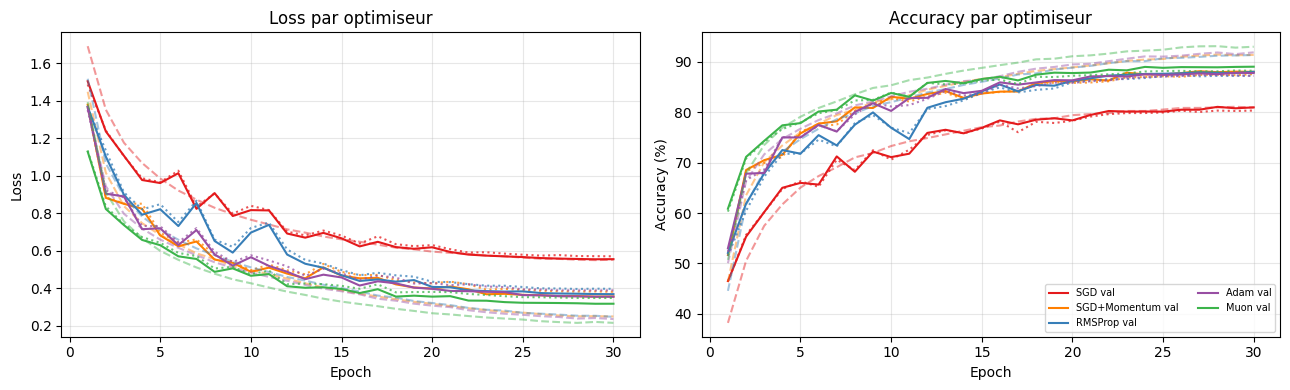

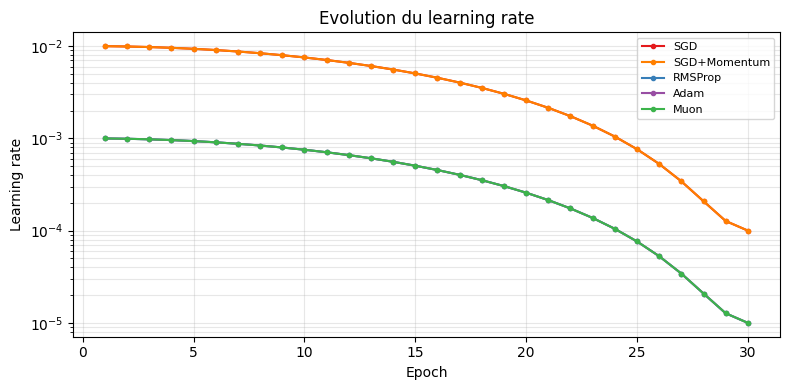

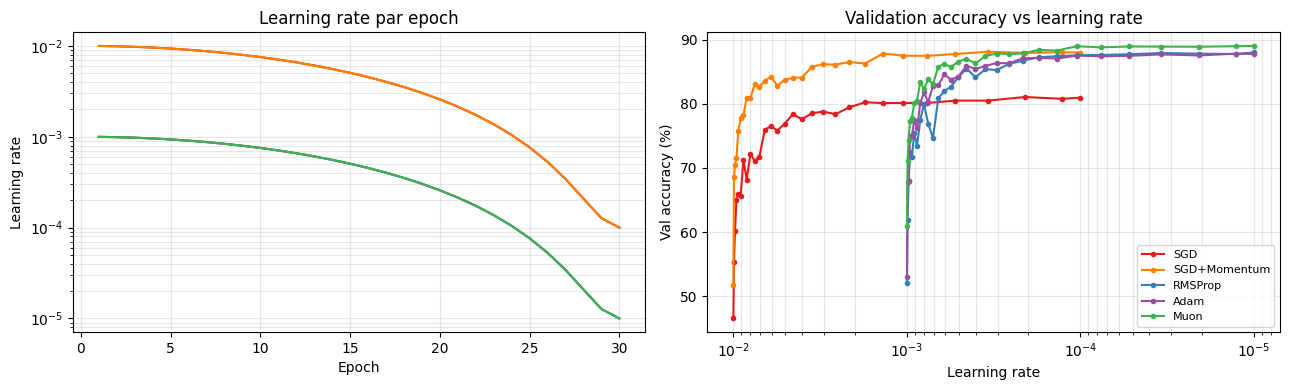

In [61]:
# ── Courbes train / validation / test ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name, res in all_results.items():
    color = COLORS.get(name)
    axes[0].plot(epochs_list, res["train_loss"], linestyle="--", color=color, alpha=0.45)
    axes[0].plot(epochs_list, res["val_loss"],   linestyle="-",  color=color, label=f"{name} val")
    axes[0].plot(epochs_list, res["test_loss"],  linestyle=":",  color=color, alpha=0.75)

    axes[1].plot(epochs_list, res["train_acc"], linestyle="--", color=color, alpha=0.45)
    axes[1].plot(epochs_list, res["val_acc"],   linestyle="-",  color=color, label=f"{name} val")
    axes[1].plot(epochs_list, res["test_acc"],  linestyle=":",  color=color, alpha=0.75)

axes[0].set_title("Loss par optimiseur")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Accuracy par optimiseur")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig("results/train_val_test_curves.png", dpi=150)
plt.show()

# ── Evolution du learning rate ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for name, res in all_results.items():
    ax.plot(epochs_list, res["lr"], marker="o", markersize=3, color=COLORS.get(name), label=name)

ax.set_title("Evolution du learning rate")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("results/lr_evolution.png", dpi=150)
plt.show()

# ── Relation learning rate / validation accuracy ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, res in all_results.items():
    color = COLORS.get(name)
    axes[0].plot(epochs_list, res["lr"], color=color, label=name)
    axes[1].plot(res["lr"], res["val_acc"], marker="o", markersize=3, color=color, label=name)

axes[0].set_title("Learning rate par epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Learning rate")
axes[0].set_yscale("log")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].set_title("Validation accuracy vs learning rate")
axes[1].set_xlabel("Learning rate")
axes[1].set_ylabel("Val accuracy (%)")
axes[1].set_xscale("log")
axes[1].invert_xaxis()
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/lr_vs_val_accuracy.png", dpi=150)
plt.show()

## 7. Tableau récapitulatif

### Synthèse des performances
Construit un tableau final avec la précision d'entraînement, la meilleure précision de validation et la précision test, l'écart de généralisation et le nombre d'époques nécessaires pour atteindre 80 %, puis sauvegarde ce résumé en CSV.


In [63]:
rows = []
for name, res in all_results.items():
    gap  = res["train_acc"][-1] - res["val_acc"][-1]
    ep80 = next((i + 1 for i, a in enumerate(res["val_acc"]) if a >= 80), None)
    rows.append({
        "Optimiseur":          name,
        "Train acc (%)": f"{res['train_acc'][-1]:.2f}",
        "Val acc (%)":   f"{max(res['val_acc']):.2f}",
        "Val precision (%)": f"{max(res['val_precision']):.2f}",
        "Test acc (%)":  f"{max(res['test_acc']):.2f}",
        "Test precision (%)": f"{max(res['test_precision']):.2f}",
        "Gap génér. (%)": f"{gap:.2f}",
        "Epochs val → 80%":  ep80 if ep80 else f">{NUM_EPOCHS}",
    })

df = pd.DataFrame(rows).set_index("Optimiseur")
display(df)

df.to_csv("results/summary_table.csv")
print("Sauvegardé : results/summary_table.csv")

,Train acc (%),Val acc (%),Val precision (%),Test acc (%),Test precision (%),Gap génér. (%),Epochs val → 80%
Optimiseur,,,,,,,
SGD,80.90,81.04,80.97,80.31,80.22,-0.04,22
SGD+Momentum,91.34,88.10,88.04,87.53,87.52,3.36,8
RMSProp,91.31,88.00,87.97,87.34,87.32,3.31,12
Adam,91.84,87.80,87.73,87.34,87.35,4.10,8
Muon,92.96,89.00,88.91,88.25,88.22,3.96,6


Sauvegardé : results/summary_table.csv
